# Computer Exercise 13.6 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.6 Interior-Point Methods for Nonlinear Programming — *Log-Barrier (Penalty) Method*
> **풀이 일자**: Day 51
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **1.** For the inequality-constrained problem
> $$\min_{x,y}\; f(x,y)=(x-2)^2+(y-2)^2 \quad \text{subject to}\quad c(x,y)=x^2+y^2-1\le 0,$$
> implement the **logarithmic barrier method**. Replace the constraint by the barrier term
> $-\mu\ln(-c(x,y))$ and solve the unconstrained subproblem $\min B_\mu(x,y)$ by **Newton's method**
> for a decreasing sequence of barrier parameters $\mu_k\to 0^+$. Trace the resulting **central path**
> $x(\mu)$ and verify that it converges to the constrained minimizer. Compare the computed path with the
> analytic central-path equation.

### 한국어 풀이용 정리
부등식 제약 $c(x,y)=x^2+y^2-1\le 0$ (단위원 안)을 **로그 장벽(log-barrier)** 항으로 바꿔
무제약 문제로 만든 뒤, 장벽모수 $\mu$를 $1\to 10^{-8}$ 로 줄여가며 각 부분문제를 **뉴턴법**으로 푼다.
각 $\mu$의 최적점이 만드는 자취가 **중심경로(central path)** $x(\mu)$이며, $\mu\to0$에서
제약 최적해 $x^\*$로 수렴함을 확인한다. 대칭성으로 얻는 **해석적 중심경로**와 비교 검증한다.

**해석해**: 무제약 최소점 $(2,2)$는 원 밖이므로 제약이 **활성(active)**.
대칭성 $x^\*=y^\*=t^\*$, 경계 $2t^2=1$ 에서 $\;x^\*=y^\*=1/\sqrt2\approx0.70711,\;
f^\*=2(2-1/\sqrt2)^2\approx3.34315,\;\lambda^\*=2\sqrt2-1\approx1.82843.$

## 2. 수학적 배경

### 2.1 장벽함수 (logarithmic barrier)
실현가능 영역 내부 $c(x)<0$ 에서만 정의되는 장벽함수

$$
B_\mu(x,y)\;=\;f(x,y)\;-\;\mu\ln\bigl(-c(x,y)\bigr)
\;=\;(x-2)^2+(y-2)^2\;-\;\mu\ln\!\bigl(1-x^2-y^2\bigr).
$$

$g\equiv -c = 1-x^2-y^2>0$ 일 때만 유한하며, 경계 $g\to0^+$ 에서 $-\mu\ln g\to+\infty$ 로
**내부에서 경계를 밀어내는 벽**을 만든다.

### 2.2 중심경로 (central path)
각 $\mu>0$의 최소점 $x(\mu)$가 만족하는 정상조건 $\nabla B_\mu=0$ 은

$$
\nabla f(x)\;+\;\frac{\mu}{g}\,\bigl(-\nabla c(x)\bigr)\cdot(-1)=0
\;\;\Longleftrightarrow\;\;
\nabla f(x)+\lambda(\mu)\,\nabla c(x)=0,\qquad
\boxed{\;\lambda(\mu)=\frac{\mu}{g}=\frac{\mu}{-c(x)}\;}
$$

즉 장벽항은 **추정 라그랑주 승수** $\lambda(\mu)=\mu/(-c)$ 를 자동으로 만든다.
$\mu\to0$ 이면 $\lambda(\mu)\to\lambda^\*$, $x(\mu)\to x^\*$ — 이것이 KKT 조건으로의 수렴이다.

### 2.3 해석적 중심경로 (대칭 축소)
$x=y=t$ 로 두면 $\nabla B_\mu=0$ 의 두 성분이 같아져 한 식으로:

$$
2(t-2)+\frac{2\mu t}{1-2t^2}=0
\;\;\Longleftrightarrow\;\;
(t-2)(1-2t^2)+\mu t=0
\;\;\Longleftrightarrow\;\;
\boxed{\,-2t^3+4t^2+(1+\mu)t-2=0\,}
$$

$(0,\,1/\sqrt2)$ 구간의 실근이 $\mu$에 대응하는 중심경로 점이다. $\mu\to0$ 에서 $t\to1/\sqrt2$.

### 2.4 뉴턴 부분문제
$\nabla B_\mu$ 와 헤시안 $\nabla^2 B_\mu$ ($g=1-x^2-y^2$):

$$
\nabla B_\mu=\begin{pmatrix}2(x-2)+\dfrac{2\mu x}{g}\\[4pt]2(y-2)+\dfrac{2\mu y}{g}\end{pmatrix},\qquad
\nabla^2 B_\mu=\begin{pmatrix}2+\dfrac{2\mu(g+2x^2)}{g^2}&\dfrac{4\mu xy}{g^2}\\[6pt]\dfrac{4\mu xy}{g^2}&2+\dfrac{2\mu(g+2y^2)}{g^2}\end{pmatrix}.
$$

뉴턴 스텝 $d=-(\nabla^2B_\mu)^{-1}\nabla B_\mu$ 에 **fraction-to-boundary** 직선탐색을 붙여 $g>0$ 유지.

## 3. 풀이 흐름

1. **문제·해석해 정의**: $f,c$ 와 그 도함수, 정확해 $x^\*=y^\*=1/\sqrt2$.
2. **장벽 부분문제 풀이기** `solve_barrier(mu, x0)`: 뉴턴 반복 + feasibility 보존 직선탐색.
3. **외부 반복(continuation)**: $\mu_0=1$ 에서 $\mu_{k+1}=0.2\,\mu_k$, warm-start 로 각 부분문제 해결.
4. **중심경로 기록**: 각 $\mu$의 $(x(\mu),y(\mu))$, $\lambda(\mu)=\mu/g$, $f$, $\|x-x^\*\|$ 저장.
5. **해석적 중심경로**: 각 $\mu$에 대해 3차식 $-2t^3+4t^2+(1+\mu)t-2=0$ 의 $(0,1/\sqrt2)$ 실근.
6. **표 출력**: $\mu$ 감소에 따른 수렴 표.
7. **시각화**: (a) 실현가능 원과 중심경로, (b) 오차·$\lambda$ 의 $\mu$ 의존성 로그그래프.
8. **해석**: 중심경로가 $x^\*$로, $\lambda(\mu)$가 $\lambda^\*$로 수렴함을 확인.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

# ---- 문제 정의 ----
def f(x):      return (x[0]-2)**2 + (x[1]-2)**2
def c(x):      return x[0]**2 + x[1]**2 - 1.0          # c<=0
def grad_f(x): return np.array([2*(x[0]-2), 2*(x[1]-2)])
def grad_c(x): return np.array([2*x[0], 2*x[1]])

# ---- 해석해 ----
xs   = 1/np.sqrt(2)
xstar = np.array([xs, xs])
fstar = f(xstar)
lamstar = 2*np.sqrt(2) - 1
print(f"해석해 x* = ({xstar[0]:.6f}, {xstar[1]:.6f}),  f* = {fstar:.6f},  lambda* = {lamstar:.6f}")


해석해 x* = (0.707107, 0.707107),  f* = 3.343146,  lambda* = 1.828427


In [2]:
def barrier_grad_hess(x, mu):
    g = 1.0 - x[0]**2 - x[1]**2          # = -c(x) > 0
    gf = grad_f(x)
    gB = gf + (mu/g)*np.array([2*x[0], 2*x[1]])
    H = np.array([
        [2 + 2*mu*(g + 2*x[0]**2)/g**2, 4*mu*x[0]*x[1]/g**2],
        [4*mu*x[0]*x[1]/g**2,           2 + 2*mu*(g + 2*x[1]**2)/g**2],
    ])
    return gB, H, g

def solve_barrier(mu, x0, tol=1e-12, itmax=100):
    x = x0.copy()
    for _ in range(itmax):
        gB, H, g = barrier_grad_hess(x, mu)
        if np.linalg.norm(gB) < tol:
            break
        d = np.linalg.solve(H, -gB)
        # fraction-to-boundary: g(x+alpha d) > 0 유지
        alpha = 1.0
        while True:
            xn = x + alpha*d
            if (1 - xn[0]**2 - xn[1]**2) > 1e-14 and f(xn) - mu*np.log(1-xn[0]**2-xn[1]**2) \
               <= f(x) - mu*np.log(g) + 1e-12:
                break
            alpha *= 0.5
            if alpha < 1e-14:
                break
        x = x + alpha*d
    return x

# ---- continuation: mu 감소 ----
mus = [1.0 * 0.2**k for k in range(11)]   # 1 -> 2e-8
x0  = np.array([0.0, 0.0])                # 실현가능 내부 출발
rows = []
for mu in mus:
    x0 = solve_barrier(mu, x0)
    g  = 1 - x0[0]**2 - x0[1]**2
    lam = mu/g
    rows.append({"mu": mu, "x": x0[0], "y": x0[1],
                 "lambda(mu)=mu/g": lam, "f": f(x0),
                 "||x-x*||": np.linalg.norm(x0-xstar),
                 "-c=g (slack)": g})
df = pd.DataFrame(rows)
df


,mu,x,y,lambda(mu)=mu/g,f,||x-x*||,-c=g (slack)
0,1.000000e+00,5.549581e-01,5.549581e-01,2.603875e+00,4.176292e+00,2.151707e-01,3.840429e-01
1,2.000000e-01,6.704981e-01,6.704981e-01,1.982857e+00,3.535151e+00,5.177247e-02,1.008646e-01
2,4.000000e-02,6.994595e-01,6.994595e-01,1.859351e+00,3.382811e+00,1.081492e-02,2.151289e-02
3,8.000000e-03,7.055634e-01,7.055634e-01,1.834614e+00,3.351132e+00,2.182677e-03,4.360590e-03
4,1.600000e-03,7.067975e-01,7.067975e-01,1.829665e+00,3.344745e+00,4.373342e-04,8.744772e-04
5,3.200000e-04,7.070449e-01,7.070449e-01,1.828675e+00,3.343466e+00,8.749889e-05,1.749901e-04
6,6.400000e-05,7.070944e-01,7.070944e-01,1.828477e+00,3.343210e+00,1.750106e-05,3.500181e-05
7,1.280000e-05,7.071043e-01,7.071043e-01,1.828437e+00,3.343159e+00,3.500263e-06,7.000515e-06
8,2.560000e-06,7.071063e-01,7.071063e-01,1.828429e+00,3.343148e+00,7.000547e-07,1.400109e-06
9,5.120000e-07,7.071067e-01,7.071067e-01,1.828428e+00,3.343146e+00,1.400110e-07,2.800220e-07


In [3]:
# ---- 해석적 중심경로와의 교차검증 ----
def analytic_t(mu):
    # -2 t^3 + 4 t^2 + (1+mu) t - 2 = 0,  근 in (0, 1/sqrt2)
    roots = np.roots([-2.0, 4.0, (1.0+mu), -2.0])
    real = roots[np.abs(roots.imag) < 1e-9].real
    cand = [r for r in real if 0 < r < 1/np.sqrt(2) + 1e-9]
    return min(cand, key=lambda r: abs(r - 1/np.sqrt(2)))

chk = pd.DataFrame({
    "mu": mus,
    "t_newton (=x=y)": df["x"].values,
    "t_analytic": [analytic_t(mu) for mu in mus],
})
chk["|diff|"] = (chk["t_newton (=x=y)"] - chk["t_analytic"]).abs()
print("뉴턴 중심경로 vs 해석적 중심경로 (3차식 실근):")
chk


뉴턴 중심경로 vs 해석적 중심경로 (3차식 실근):


,mu,t_newton (=x=y),t_analytic,|diff|
0,1.000000e+00,5.549581e-01,5.549581e-01,1.110223e-16
1,2.000000e-01,6.704981e-01,6.704981e-01,1.110223e-16
2,4.000000e-02,6.994595e-01,6.994595e-01,2.220446e-16
3,8.000000e-03,7.055634e-01,7.055634e-01,2.220446e-16
4,1.600000e-03,7.067975e-01,7.067975e-01,2.220446e-16
5,3.200000e-04,7.070449e-01,7.070449e-01,1.110223e-16
6,6.400000e-05,7.070944e-01,7.070944e-01,0.000000e+00
7,1.280000e-05,7.071043e-01,7.071043e-01,1.110223e-16
8,2.560000e-06,7.071063e-01,7.071063e-01,1.110223e-16
9,5.120000e-07,7.071067e-01,7.071067e-01,1.110223e-16


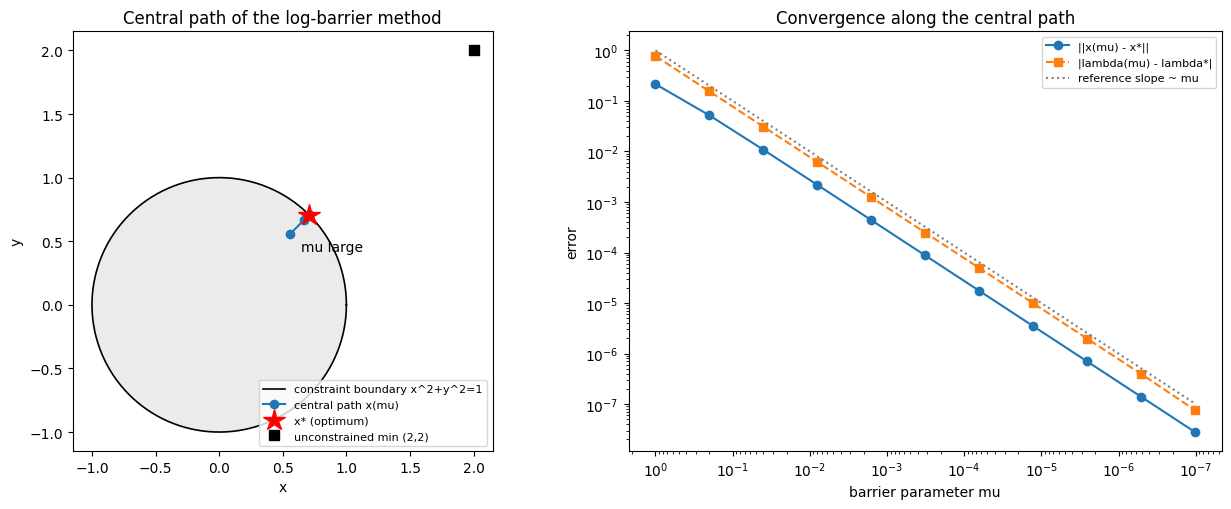

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# (a) feasible disk + central path
ax = axes[0]
th = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(th), np.sin(th), 'k-', lw=1.2, label="constraint boundary x^2+y^2=1")
ax.fill(np.cos(th), np.sin(th), color="0.92")
ax.plot(df["x"], df["y"], 'o-', color="tab:blue", label="central path x(mu)")
ax.plot(*xstar, 'r*', ms=16, label="x* (optimum)")
ax.plot(2, 2, 'ks', ms=7, label="unconstrained min (2,2)")
ax.annotate("mu large", (df["x"].iloc[0], df["y"].iloc[0]),
            textcoords="offset points", xytext=(8, -12))
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
ax.set_title("Central path of the log-barrier method"); ax.legend(loc="lower right", fontsize=8)

# (b) error and lambda vs mu
ax = axes[1]
ax.loglog(df["mu"], df["||x-x*||"], 'o-', label="||x(mu) - x*||")
ax.loglog(df["mu"], np.abs(df["lambda(mu)=mu/g"] - lamstar), 's--',
          label="|lambda(mu) - lambda*|")
ax.loglog(df["mu"], df["mu"], ':', color="0.5", label="reference slope ~ mu")
ax.set_xlabel("barrier parameter mu"); ax.set_ylabel("error")
ax.set_title("Convergence along the central path"); ax.legend(fontsize=8)
ax.invert_xaxis()
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **중심경로의 수렴**: $\mu$가 $1\to10^{-8}$ 로 줄면서 $x(\mu)$ 는 무제약 최소점 쪽에서 출발해
   실현가능 영역 내부를 지나 경계 위의 $x^\*=(1/\sqrt2,1/\sqrt2)$ 로 **매끄럽게** 접근한다.
2. **승수의 복원**: 장벽이 자동 생성한 $\lambda(\mu)=\mu/(-c)$ 가 $\lambda^\*=2\sqrt2-1\approx1.828$ 로 수렴 —
   장벽법이 무제약화 속에서도 KKT 승수를 회복함을 보여준다.
3. **선형(1차) 수렴**: 오차 $\|x(\mu)-x^\*\|$ 와 $|\lambda(\mu)-\lambda^\*|$ 가 모두 **$\mu$에 비례**($\mathcal O(\mu)$).
   따라서 단순 장벽법의 정확도는 $\mu$를 얼마나 작게 하느냐에 직접 묶여 있다.
4. **해석해 교차검증**: 뉴턴 부분문제 해가 3차식 $-2t^3+4t^2+(1+\mu)t-2=0$ 의 실근과
   기계정밀도 수준으로 일치 — 구현이 옳다는 강한 증거.

### 결론
> **로그 장벽법은 부등식 제약을 "내부에서 미는 벽"으로 바꿔 무제약 뉴턴 문제의 연속체로 풀며,
> 중심경로를 따라 $x(\mu)\to x^\*$, $\lambda(\mu)\to\lambda^\*$ 로 $\mathcal O(\mu)$ 수렴한다.**

**다음 문제로의 연결**: 부분문제를 매번 끝까지 푸는 대신, KKT 방정식을 직접 섭동시켜
$x,\lambda,s$ 를 **동시에** 뉴턴 갱신하는 **원-쌍대(primal-dual) 내부점법** (Problem 2)이
같은 중심경로를 훨씬 빠르고 안정적으로 추적한다.